In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Loan_Fraud_Dataset.csv to Loan_Fraud_Dataset.csv


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Dataset info**

In [7]:
df = pd.read_csv("Loan_Fraud_Dataset.csv")

In [8]:
print(df.head())

   ip_region_mismatch  device_change_rate  application_frequency  loan_amount  \
0                   1            0.214951                      1       599342   
1                   0            0.099624                      0       472347   
2                   0            0.251592                      0       629537   
3                   0            0.149156                      1       804605   
4                   0            0.372081                      2       453169   

  institution  loan_type  session_duration  geo_location_consistency  \
0       Kotak       Home        176.683027                         0   
1        Axis       Home        126.025415                         1   
2       ICICI  Education        388.031010                         1   
3       ICICI        Car        455.770985                         1   
4         SBI        Car        407.537671                         1   

   previous_defaults  time_between_apps  browser_fingerprint_change  \
0        

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ip_region_mismatch          10000 non-null  int64  
 1   device_change_rate          10000 non-null  float64
 2   application_frequency       10000 non-null  int64  
 3   loan_amount                 10000 non-null  int64  
 4   institution                 10000 non-null  object 
 5   loan_type                   10000 non-null  object 
 6   session_duration            10000 non-null  float64
 7   geo_location_consistency    10000 non-null  int64  
 8   previous_defaults           10000 non-null  int64  
 9   time_between_apps           10000 non-null  float64
 10  browser_fingerprint_change  10000 non-null  float64
 11  fraudulent                  10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB
None


In [10]:
print(df.columns)

Index(['ip_region_mismatch', 'device_change_rate', 'application_frequency',
       'loan_amount', 'institution', 'loan_type', 'session_duration',
       'geo_location_consistency', 'previous_defaults', 'time_between_apps',
       'browser_fingerprint_change', 'fraudulent'],
      dtype='object')


In [11]:
print(df.describe())

       ip_region_mismatch  device_change_rate  application_frequency  \
count        10000.000000        10000.000000           10000.000000   
mean             0.150500            0.166759               2.012600   
std              0.357579            0.101998               1.432147   
min              0.000000            0.001397               0.000000   
25%              0.000000            0.088197               1.000000   
50%              0.000000            0.149337               2.000000   
75%              0.000000            0.228422               3.000000   
max              1.000000            0.659256              10.000000   

        loan_amount  session_duration  geo_location_consistency  \
count  1.000000e+04      10000.000000              10000.000000   
mean   5.004758e+05        297.334350                  0.908500   
std    1.983502e+05         99.469377                  0.288333   
min    5.000000e+04         30.000000                  0.000000   
25%    3.654810e

**DataSet Cleaning**

In [12]:
print(df.isnull().sum())

ip_region_mismatch            0
device_change_rate            0
application_frequency         0
loan_amount                   0
institution                   0
loan_type                     0
session_duration              0
geo_location_consistency      0
previous_defaults             0
time_between_apps             0
browser_fingerprint_change    0
fraudulent                    0
dtype: int64


In [13]:
print(df.duplicated().sum())

0


**Exploratory Data Analysis (EDA)**

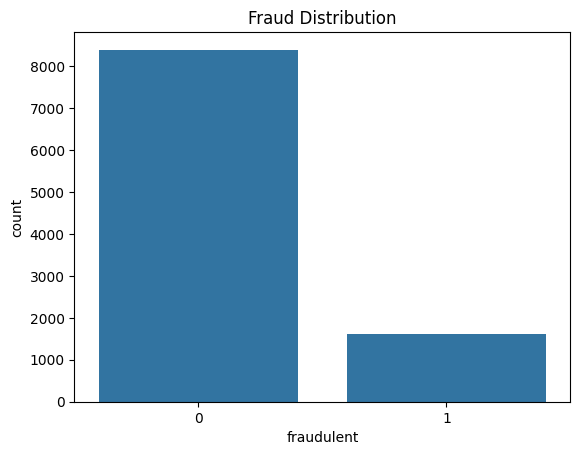

In [14]:
sns.countplot(x='fraudulent', data=df)
plt.title('Fraud Distribution')
plt.show()

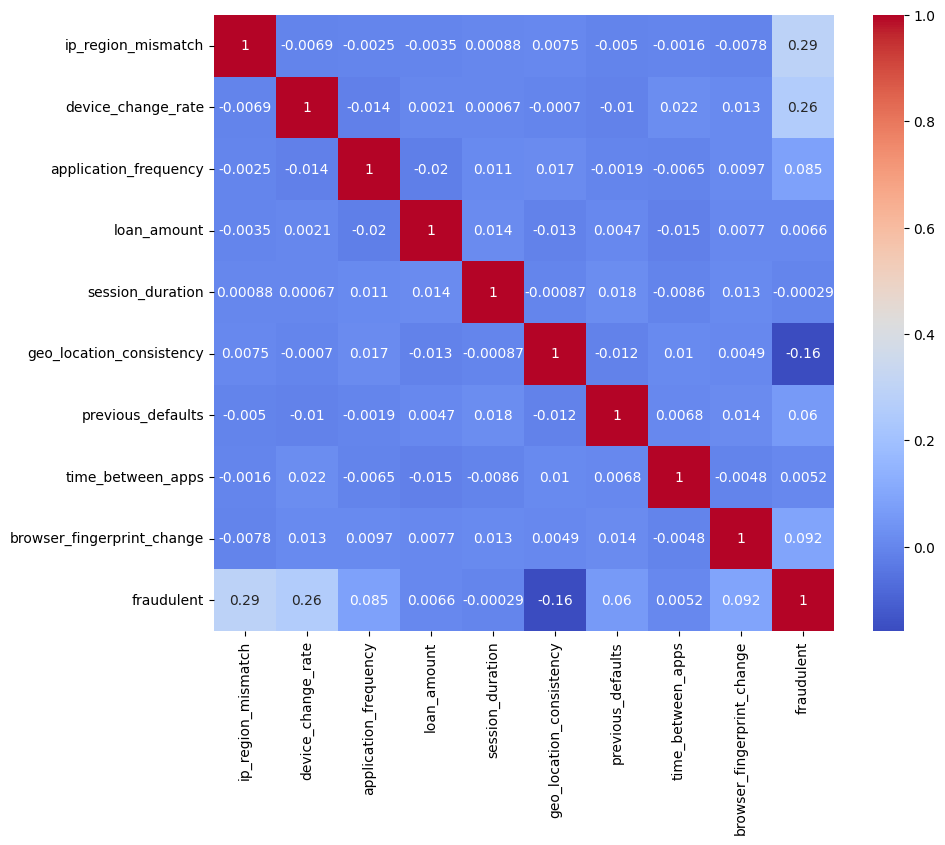

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

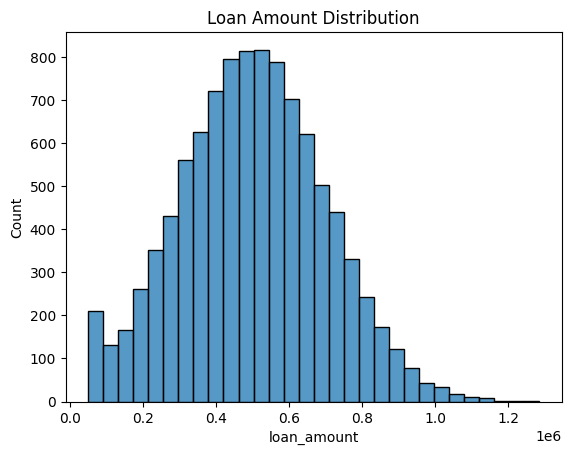

In [16]:
sns.histplot(df['loan_amount'], bins=30)
plt.title('Loan Amount Distribution')
plt.show()

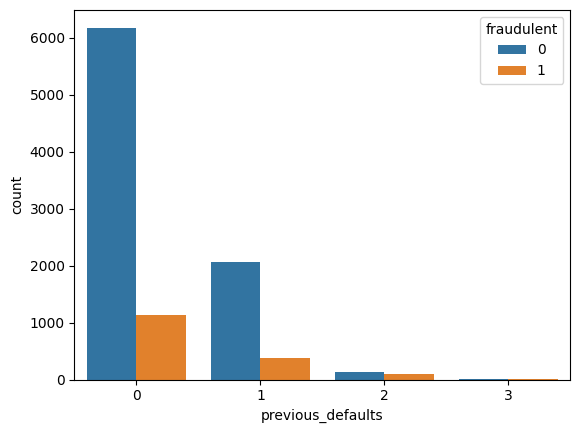

In [17]:
sns.countplot(
    x='previous_defaults',
    hue='fraudulent',
    data=df
)

plt.show()

**Check categorical columns:**

In [18]:
print(df.select_dtypes(include='object').columns)

Index(['institution', 'loan_type'], dtype='object')


In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

In [20]:
print(df.head())

   ip_region_mismatch  device_change_rate  application_frequency  loan_amount  \
0                   1            0.214951                      1       599342   
1                   0            0.099624                      0       472347   
2                   0            0.251592                      0       629537   
3                   0            0.149156                      1       804605   
4                   0            0.372081                      2       453169   

   institution  loan_type  session_duration  geo_location_consistency  \
0            4          2        176.683027                         0   
1            0          2        126.025415                         1   
2            3          1        388.031010                         1   
3            3          0        455.770985                         1   
4            5          0        407.537671                         1   

   previous_defaults  time_between_apps  browser_fingerprint_change  \
0  

**Feature Selection**

In [21]:
y = df['fraudulent']

In [22]:
X = df.drop('fraudulent', axis=1)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Isolation Forest**

In [24]:
from sklearn.ensemble import IsolationForest

In [25]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [26]:
iso.fit(X)

IsolationForest(contamination=0.05, random_state=42)

In [28]:
pred = iso.predict(X)

In [29]:
df['anomaly'] = pred

In [30]:
print(df['anomaly'].value_counts())

anomaly
 1    9500
-1     500
Name: count, dtype: int64


**K-Means Clustering**

In [31]:
from sklearn.cluster import KMeans

In [32]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [33]:
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

In [34]:
print(df['cluster'].value_counts())

cluster
0    5058
1    4942
Name: count, dtype: int64


**Random Forest Classification**

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [36]:
y_pred = rf.predict(X_test)

**Evaluate Model**

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1680
           1       0.55      0.20      0.30       320

    accuracy                           0.85      2000
   macro avg       0.71      0.59      0.61      2000
weighted avg       0.81      0.85      0.81      2000



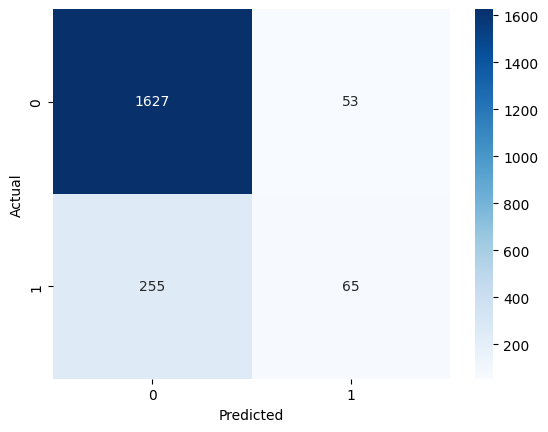

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Feature Importance**

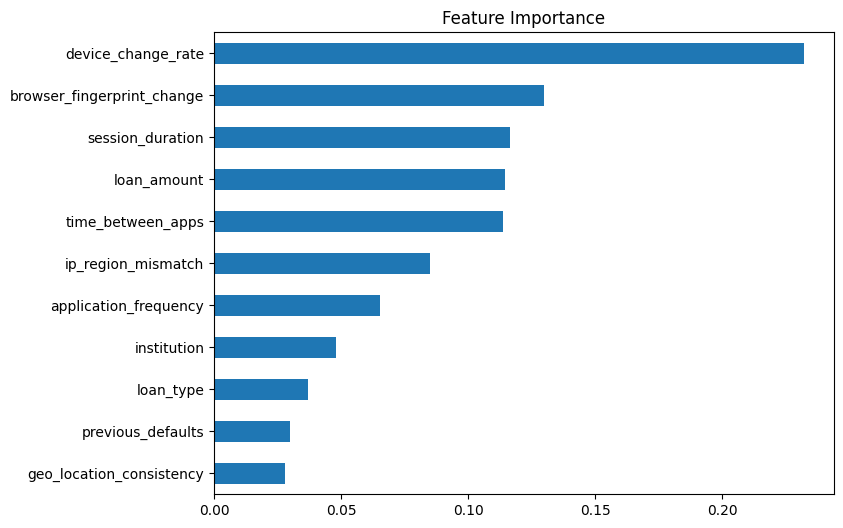

In [40]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

**Fraud Alert System**

In [42]:
df['alert'] = np.where(
    df['anomaly']==-1,
    'Fraud Alert',
    'Normal'
)
print(df[['fraudulent','anomaly','alert']].head())

   fraudulent  anomaly        alert
0           0       -1  Fraud Alert
1           0        1       Normal
2           0        1       Normal
3           0        1       Normal
4           0        1       Normal


**Accuracy Score**

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.846


**Precision, Recall, and F1 Score**

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.5508474576271186
Recall: 0.203125
F1 Score: 0.2968036529680365


**ROC-AUC Score**

In [45]:
from sklearn.metrics import roc_auc_score

probabilities = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8522144717261905


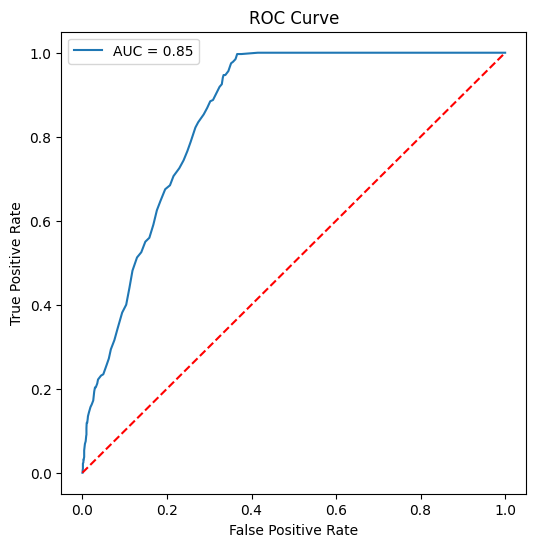

In [58]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**fraud alert **

In [59]:
df['alert'] = np.where(
    df['anomaly']==-1,
    "⚠ Fraud Alert",
    "Normal"
)

print(df[['fraudulent','anomaly','alert']].head(10))

   fraudulent  anomaly          alert
0           0       -1  ⚠ Fraud Alert
1           0        1         Normal
2           0        1         Normal
3           0        1         Normal
4           0        1         Normal
5           0        1         Normal
6           0        1         Normal
7           1       -1  ⚠ Fraud Alert
8           0        1         Normal
9           0        1         Normal


In [47]:
import pickle
pickle.dump(rf, open('random_forest_model.pkl', 'wb'))
pickle.dump(iso, open('isolation_forest_model.pkl', 'wb'))

In [48]:
loaded_model = pickle.load(open('random_forest_model.pkl', 'rb'))

**Predict New Applications**

In [49]:
new_application = [[
    1,
    0.4,
    7,
    50000,
    2,
    1,
    300,
    0.8,
    0,
    25,
    0.2
]]

prediction = loaded_model.predict(new_application)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [60]:
import pickle

pickle.dump(rf, open("random_forest_model.pkl","wb"))
pickle.dump(iso, open("isolation_forest_model.pkl","wb"))

In [61]:
from google.colab import files

files.download("random_forest_model.pkl")
files.download("isolation_forest_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
model = pickle.load(open("random_forest_model.pkl", "rb"))

In [63]:
obj = pickle.load(open("random_forest_model.pkl", "rb"))

print(obj)
print(type(obj))

RandomForestClassifier(random_state=42)
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
